# Relazioni Non-Lineari: Funzioni Base e Regressione Logistica

## 1. Introduzione alle Relazioni Non-Lineari

Nella regressione lineare standard, modelliamo la relazione tra input e output come:

$$y(x, w) = w_1 x + w_0$$

Questo approccio presuppone che i dati seguano una relazione lineare. Tuttavia, molti fenomeni reali presentano relazioni non-lineari dove questo modello risulta inadeguato.

Le relazioni non-lineari possono essere modellate in due modi principali:

- Utilizzando funzioni base per trasformare l'input
- Utilizzando modelli intrinsecamente non-lineari (es. reti neurali)

## 2. Formulazione Matematica

### Modello di Regressione con Funzioni Base

Un modello non-lineare può essere espresso utilizzando funzioni base come:

$$y(x, w) = \sum_{j=0}^{N} w_j \phi_j(x)$$

Dove:

- $x$ è un vettore di caratteristiche descrittive
- $w$ è un vettore di pesi
- $\phi_j(x)$ è una serie di N funzioni base che trasformano l'input in modo diverso

È importante notare che N non deve necessariamente essere uguale al numero di caratteristiche originali d, e tipicamente N > d.

### Funzione di Errore

$$E(y, w) = \frac{1}{2m} \sum\limits_{n = 0}^{m-1} (y(x_n, w) - t_n)^2$$

## 3. Funzioni Base

Le funzioni base trasformano le variabili di input in nuove rappresentazioni, permettendo di catturare relazioni non-lineari. Ecco alcune funzioni base comuni:

- $\phi_0(x) = 1$ (termine costante/bias)
- $\phi_1(x) = x$ (funzione identità)
- $\phi_2(x) = x^2$ (quadratica)
- $\phi_3(x) = x^3$ (cubica)
- $\phi_4(x) = \sin(x)$ (sinusoidale)
- $\phi_5(x) = e^x$ (esponenziale)
- $\phi_6(x) = \log(x)$ (logaritmica)
- $\phi_7(x) = x_1 \times x_2$ (interazione tra feature)

## 4. Regressione Logistica Non-Lineare

### Formulazione del Modello

La regressione logistica può essere estesa per catturare relazioni non-lineari incorporando funzioni base:

$$y(x, w) = \frac{1}{1 + e^{-(\sum_{j=0}^{M} w_j\phi_j(x))}}$$

Questo approccio mantiene la struttura della regressione logistica ma permette di modellare confini di decisione non-lineari.

### Addestramento con Gradient Descent

Il modello viene addestrato utilizzando la discesa del gradiente per trovare i pesi ottimali $w$ che minimizzano la funzione di costo (log loss):

$$J(w) = -\frac{1}{N} \sum_{i=1}^{N} [t^{(i)} \log(y(x^{(i)}, w)) + (1-t^{(i)}) \log(1-y(x^{(i)}, w))]$$

Il gradiente di questa funzione rispetto ai pesi è:

$$\nabla J(w) = \frac{1}{N} \sum_{i=1}^{N} (y(x^{(i)}, w) - t^{(i)}) \phi(x^{(i)})$$


# 5. Esempio di Applicazione: Dataset IoT e Propagazione del Segnale

Nel contesto delle telecomunicazioni , spesso le relazioni sono intrinsecamente non lineari. In questo notebook esploreremo un caso studio sulla qualità del segnale ricevuto dai dispositivi, dove diversi fattori influenzano in modo non lineare la ricezione del segnale.

## 5.1 Carichiamo il dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.optimize import curve_fit

# Rileggi il dataset dal file CSV
df_loaded = pd.read_csv('signal_data.csv')

df_loaded.head()  # Mostra le prime righe del dataframe

,distance,obstacles,temperature,humidity,signal_quality,signal_class
0,1.935247,6.981617,7.405317,56.335725,0.170186,0
1,4.758500,5.360964,21.676038,53.542731,0.000000,0
2,3.686770,3.095276,34.917833,21.794945,0.000000,0
3,3.033427,8.137950,29.288995,43.887348,0.000000,0
4,0.864491,6.847312,32.262446,46.613693,7.663143,1


# Due target features:
- signal_quality - valori continui, si tratta di regressione
- signal_class - valori discreti, si tratta di classificazione (binaria)

Con signal class intendiamo un segnale buono con la classe 1, un segnale debole con classe 0

In un flusso di lavoro reale di Machine Learning, si partirebbe dall’esplorazione dei dati.
Qui la manteniamo al minimo e ci concentriamo sul confronto tra modelli.

In [2]:
df_loaded.info()  # Mostra informazioni sul dataframe

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   distance        500 non-null    float64
 1   obstacles       500 non-null    float64
 2   temperature     500 non-null    float64
 3   humidity        500 non-null    float64
 4   signal_quality  500 non-null    float64
 5   signal_class    500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [3]:
# Estrai le features e le etichette
distance = df_loaded['distance'].values
obstacles = df_loaded['obstacles'].values
temperature = df_loaded['temperature'].values
humidity = df_loaded['humidity'].values
signal_quality = df_loaded['signal_quality'].values
signal_class = df_loaded['signal_class'].values
X = np.column_stack([distance, obstacles, temperature, humidity])
y = signal_class
n_samples = X.shape[0]

print(pd.Series(signal_class).value_counts())

0    250
1    250
Name: count, dtype: int64


Verifichiamo la distribuzione delle classi per capire se il dataset è bilanciato.

In questo caso, le classi sono ben bilanciate, quindi non ci aspettiamo problemi legati allo sbilanciamento.

## Informazione e trasformazioni delle feature

Abbiamo già utilizzato la correlazione e la Mutual Information per valutare quanto una feature è informativa rispetto al target.

Qui però siamo interessati a un altro aspetto: la forma della relazione tra le feature e il target.

- Feature selection → correlazione / Mutual Information  
- Feature transformation → visualizzazione (scatter plot)

Misure come correlazione e Mutual Information ci dicono *quanto* una feature è informativa, ma non ci permettono di capire *come* è fatta la relazione.

Per questo utilizziamo i grafici per osservare la struttura dei dati e individuare eventuali relazioni non lineari.

## Visualizzazione dello spazio delle feature

Prima di addestrare i modelli, osserviamo i dati nello spazio delle feature per capire
se le classi sembrano separabili e se possono essere utili modelli lineari o non lineari.

Facciamo questo prima di split e normalizzazione per non perdere interpretazione dei dati

target continuo → scatter diretto funziona bene  
target discreto → feature vs feature, colore = target (scegliere le coppie in modo ragionato - domain knowledge)

Con signal class intendiamo un segnale buono con la classe 1, un segnale debole con classe 0

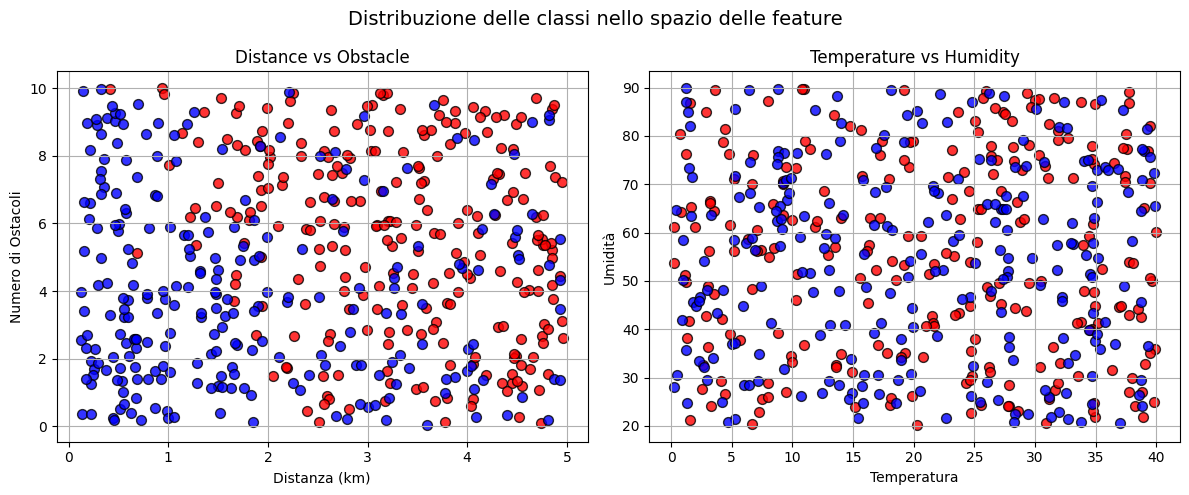

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_plot = pd.DataFrame(X, columns=['distance', 'obstacles', 'temperature', 'humidity'])
df_plot['signal_class'] = y

plt.figure(figsize=(12, 5))

colors = ['red', 'blue']
labels = ['Segnale Scarso', 'Segnale Buono']


# Scatter plot su signal_class
plt.subplot(1, 2, 1)
# scatter1 = plt.scatter(distance, obstacles, c=signal_class, cmap='coolwarm', 
#           alpha=0.8, s=50, edgecolor='k')
for i in range(2):
    idx = np.where(signal_class == i)
    plt.scatter(distance[idx], obstacles[idx],
                c=colors[i], alpha=0.8, s=50, edgecolor='k',
                label=labels[i])
plt.xlabel('Distanza (km)')
plt.ylabel('Numero di Ostacoli')
plt.title('Distance vs Obstacle')
plt.grid(True)


# Visualizziamo la nuova distribuzione
plt.subplot(1, 2, 2)
# scatter2 = plt.scatter(temperature, humidity, c=signal_class, cmap='coolwarm', 
#           alpha=0.8, s=50, edgecolor='k')
for i in range(2):
    idx = np.where(signal_class == i)
    plt.scatter(temperature[idx], humidity[idx],
                c=colors[i], alpha=0.8, s=50, edgecolor='k',
                label=labels[i])
plt.xlabel('Temperatura')
plt.ylabel('Umidità')
plt.title('Temperature vs Humidity')
plt.grid(True)

plt.suptitle('Distribuzione delle classi nello spazio delle feature', fontsize=14)
plt.tight_layout()
plt.show()



## Analisi dei grafici e possibili trasformazioni

Dai grafici possiamo osservare alcuni pattern utili per scegliere le trasformazioni delle feature.

### Classificazione (signal_class)

- **Distance vs Obstacles**  
  Le classi mostrano una certa separazione nello spazio delle feature.  
  Tuttavia, la separazione non è perfettamente lineare → potrebbe essere utile introdurre trasformazioni non lineari o combinazioni tra le feature.

- **Temperature vs Humidity**  
  Non emerge una separazione evidente tra le classi.  
  → queste feature, da sole, potrebbero essere meno informative per la classificazione.

Nel caso della classificazione, i grafici mostrano che la separazione tra le classi non è chiaramente lineare.

Non è semplice dedurre una trasformazione specifica dalla forma dei dati.

Per questo motivo, invece di scegliere una trasformazione “mirata”, utilizziamo delle **trasformazioni più generali (basis functions)** che permettono al modello di apprendere automaticamente confini decisionali non lineari.

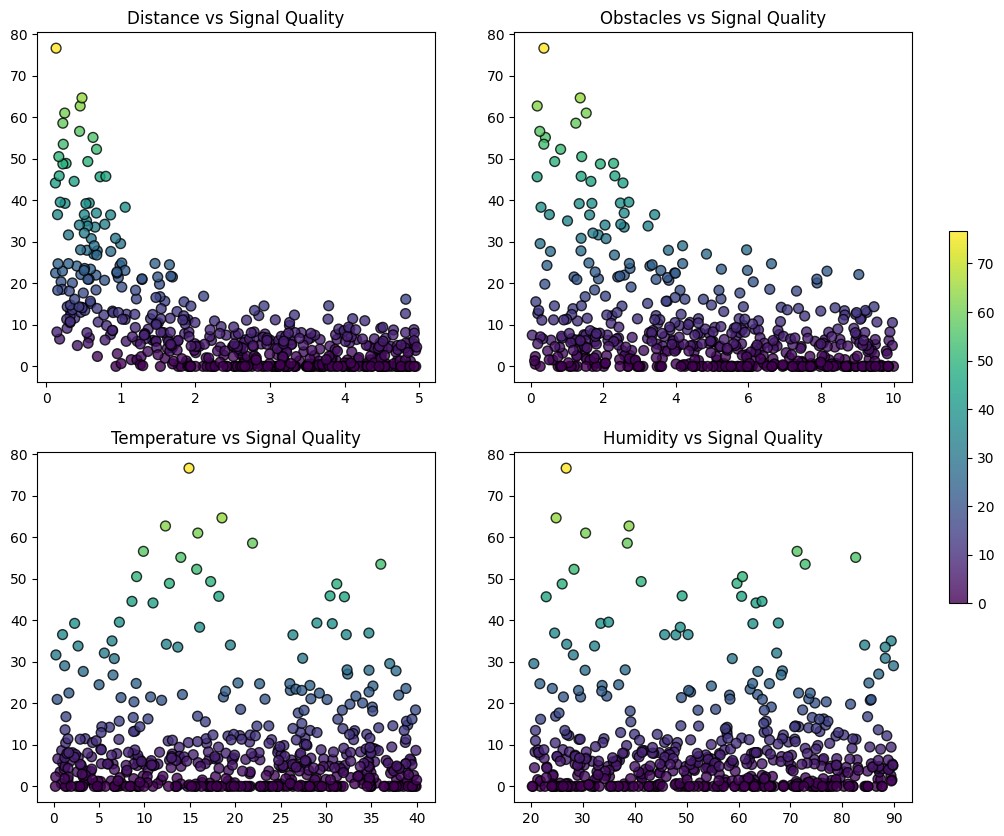

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1
sc = axes[0, 0].scatter(distance, signal_quality, c=signal_quality, cmap='viridis',
                        alpha=0.8, s=50, edgecolor='k')
axes[0, 0].set_title('Distance vs Signal Quality')

# 2
axes[0, 1].scatter(obstacles, signal_quality, c=signal_quality, cmap='viridis',
                   alpha=0.8, s=50, edgecolor='k')
axes[0, 1].set_title('Obstacles vs Signal Quality')

# 3
axes[1, 0].scatter(temperature, signal_quality, c=signal_quality, cmap='viridis',
                   alpha=0.8, s=50, edgecolor='k')
axes[1, 0].set_title('Temperature vs Signal Quality')

# 4
axes[1, 1].scatter(humidity, signal_quality, c=signal_quality, cmap='viridis',
                   alpha=0.8, s=50, edgecolor='k')
axes[1, 1].set_title('Humidity vs Signal Quality')

# colorbar corretta
fig.colorbar(sc, ax=axes, fraction=0.02, pad=0.04)

plt.show()

## Analisi dei grafici e possibili trasformazioni

Dai grafici possiamo osservare alcuni pattern utili per scegliere le trasformazioni delle feature.

### Regressione (signal_quality)

- **Distance vs Signal Quality**  
  La qualità del segnale decresce rapidamente all’aumentare della distanza.  
  → possibile relazione **non lineare**, ad esempio del tipo:
  - \( 1/x \)
  - \( log(x) \)

- **Obstacles vs Signal Quality**  
  Andamento simile: più ostacoli → qualità più bassa.  
  → anche qui una trasformazione non lineare può essere utile.

- **Temperature vs Signal Quality**  
  Si osserva un andamento a **campana (parabola rovesciata)**:  
  valori medi di temperatura → qualità più alta.  
  → possibile trasformazione:
  - \( x^2 \) (termine quadratico)

- **Humidity vs Signal Quality**  
  Pattern simile alla temperatura, anche se meno evidente.  
  → possibile relazione non lineare, ma più debole.


## Suddivisione del dataset

Dividiamo il dataset in tre parti:

- Training set: per addestrare i modelli
- Validation set: per confrontare diverse soluzioni
- Test set: per la valutazione finale

In questo modo evitiamo di scegliere il modello direttamente sul test set.

In [6]:
# Split train+val / test - 500 istanze: 400 temp e 100 test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split train / validation - delle 400 istanze temp faccio un'altra suddivisione (25%): 300 train e 100 validazione
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 * 0.8 = 0.2
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (300, 4)
Validation: (100, 4)
Test: (100, 4)


## Scelta della suddivisione del dataset

In generale, la strategia di suddivisione del dataset dipende dal problema e dal tipo di target:

- classificazione con classi sbilanciate → si utilizza uno **stratified split**
- serie temporali (regressione) → si utilizza uno **time-based split**
- dati con gruppi/soggetti → si utilizza uno **grouped split**

Nel nostro caso abbiamo:

- lo stesso dataset con due target collegati:
  - `signal_quality` (variabile continua)
  - `signal_class` (variabile discreta)
- nessuna vera struttura temporale
- classificazione binaria con classi bilanciate o quasi

Per questo motivo, per confrontare i due punti di vista sullo stesso problema, utilizziamo la **stessa suddivisione dei campioni**. 

## Normalizzazione delle feature

Normalizziamo le feature per migliorare l’addestramento dei modelli.

La normalizzazione viene calcolata solo sul training set e poi applicata anche a validation e test set, per evitare data leakage.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit SOLO sul training - calcola media e deviazione standard delle feature del training set
X_train_scaled = scaler.fit_transform(X_train)

# Transform sugli altri
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Scelta dei modelli

## Iniziamo con la Classificazione

Definiamo una **regressione logistica non lineari** applicando delle funzioni base come trasformazioni: invece di scegliere una trasformazione mirata, espandiamo lo spazio delle feature (termini quadratici e interazioni) per permettere al modello di apprendere confini decisionali non lineari.

Useremo sempre lo stesso classificatore: la regressione logistica.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class ManualLogisticRegression:
    """
    Implementazione da zero della regressione logistica
    utilizzando la discesa del gradiente.
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
        self.feature_names = None
    
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def predict_raw(self, X):
        """
        Calcola la combinazione lineare:
        z = Xw + b
        """
        return np.dot(X, self.weights) + self.bias

    def compute_cost(self, X, y):
        """
        Calcola la binary cross-entropy.
        """
        m = X.shape[0]
        z = self.predict_raw(X)
        h = self.sigmoid(z)
        
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)
        
        cost = -1 / m * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
        return cost
    
    def compute_gradient(self, X, y):
        """
        Calcola i gradienti rispetto a pesi e bias.
        """
        m = X.shape[0]
        z = self.predict_raw(X)
        h = self.sigmoid(z)
        
        error = h - y
        
        dw = 1 / m * np.dot(X.T, error)
        db = 1 / m * np.sum(error)
        
        return dw, db

    def gradient_descent(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0.0
        self.cost_history = []
        
        for i in range(self.n_iterations):
            dw, db = self.compute_gradient(X, y)
            
            self.weights = self.weights - self.learning_rate * dw
            self.bias = self.bias - self.learning_rate * db
            
            cost = self.compute_cost(X, y)
            self.cost_history.append(cost)
            
            if (i % 100 == 0) or (i == self.n_iterations - 1):
                print(f"Iterazione {i}: Costo = {cost:.6f}")
    
    def fit(self, X, y):
        X_array = X.values if isinstance(X, pd.DataFrame) else np.asarray(X)
        y_array = y.values if isinstance(y, pd.Series) else np.asarray(y)
        
        y_array = y_array.reshape(-1)
        
        print("Avvio addestramento...")
        self.gradient_descent(X_array, y_array)
        print("Addestramento completato!")
        
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
    
    def predict_proba(self, X):
        X_array = X.values if isinstance(X, pd.DataFrame) else np.asarray(X)
        return self.sigmoid(self.predict_raw(X_array))
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def plot_cost_history(self):
        plt.figure(figsize=(10, 6))
        plt.plot(range(len(self.cost_history)), self.cost_history)
        plt.xlabel("Iterazioni")
        plt.ylabel("Costo")
        plt.title("Andamento della funzione di costo")
        plt.grid(True)
        plt.show()

### Trasformazioni delle feature (basis functions)

Per rendere più flessibile il modello, trasformiamo le feature originali.

Useremo alcune trasformazioni semplici:

- **linear**: nessuna trasformazione
- **quadratic**: aggiunge i termini al quadrato (x²)
- **interaction**: aggiunge prodotti tra feature (x₁·x₂)
- **quadratic_interaction**: combina entrambe

Il classificatore resta lo stesso (regressione logistica), ma cambia lo spazio delle feature.

Per ottenere confini decisionali più flessibili, non cambiamo il modello, ma cambiamo la rappresentazione dei dati attraverso alcune trasformazioni delle feature.

In [9]:
def apply_basis_transformation(X, basis="linear"):
    """
    Applica una trasformazione alle feature.

    Parametri:
    - X: array numpy o DataFrame (già scalato)
    - basis: tipo di trasformazione

    Possibili valori:
    - "linear": nessuna trasformazione
    - "quadratic": aggiunge i termini al quadrato
    - "interaction": aggiunge prodotti tra coppie di feature
    - "quadratic_interaction": combina entrambe (quadratic + interaction)

    Non perdiamo le feature originali (lineari) nelle trasformazioni.
    linear: 4 feature
    quadratic: 8 feature
    interaction: 10 feature
    quadratic_interaction: 14 feature
    Se un termine non serve, il modello dovrebbe mettere il relativo peso a 0
    """

    # Convertiamo in numpy array
    X = X.values if hasattr(X, "values") else X
    X = np.asarray(X)

    features = [X]

    n_features = X.shape[1]

    # --- Quadratic terms ---
    if basis in ["quadratic", "quadratic_interaction"]:
        X_squared = X ** 2
        features.append(X_squared)

    # --- Interaction terms ---
    if basis in ["interaction", "quadratic_interaction"]:
        interaction_terms = []
        for i in range(n_features):
            for j in range(i + 1, n_features):
                interaction = (X[:, i] * X[:, j]).reshape(-1, 1)
                interaction_terms.append(interaction)

        if interaction_terms:
            interaction_matrix = np.hstack(interaction_terms)
            features.append(interaction_matrix)

    # Concatenazione finale
    return np.hstack(features)

## Confronto tra diverse trasformazioni e modelli

In questa sezione:

- applichiamo diverse trasformazioni alle feature;
- usiamo sempre la regressione logistica;
- confrontiamo:
  - implementazione da zero
  - implementazione di scikit-learn

L'obiettivo è capire come cambiano le prestazioni al variare della rappresentazione dei dati.

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

basis_list = ["linear", "quadratic", "interaction", "quadratic_interaction"]

results = []
models_dict = {}

for basis in basis_list:
    
    # Trasformazioni
    Xtr = apply_basis_transformation(X_train_scaled, basis)
    Xval = apply_basis_transformation(X_val_scaled, basis)
    
    # -----------------------
    # MODELLO DA ZERO
    # -----------------------
    print("Training Manual model...")
    manual_model = ManualLogisticRegression(
        learning_rate=0.01,
        n_iterations=2000
    )
    
    manual_model.fit(Xtr, y_train)
    
    ytr_pred = manual_model.predict(Xtr)
    yval_pred = manual_model.predict(Xval)
    
    train_metrics = compute_metrics(y_train, ytr_pred)
    val_metrics = compute_metrics(y_val, yval_pred)  

    results.append({
        "Model": "Manual",
        "Basis": basis,
        "Train Accuracy": train_metrics["Accuracy"],
        "Train Precision": train_metrics["Precision"],
        "Train Recall": train_metrics["Recall"],
        "Train F1": train_metrics["F1"],
        "Val Accuracy": val_metrics["Accuracy"],
        "Val Precision": val_metrics["Precision"],
        "Val Recall": val_metrics["Recall"],
        "Val F1": val_metrics["F1"]
    })
    
    models_dict[("Manual", basis)] = manual_model
    
    
    # -----------------------
    # SCIKIT-LEARN
    # -----------------------
    print("Training Sklearn model...")     # scikit learn non stampa nulla!!
    sk_model = LogisticRegression(max_iter=1000)
    sk_model.fit(Xtr, y_train)
    
    ytr_pred = sk_model.predict(Xtr)
    yval_pred = sk_model.predict(Xval)

    train_metrics = compute_metrics(y_train, ytr_pred)
    val_metrics = compute_metrics(y_val, yval_pred)
    
    results.append({
        "Model": "Sklearn",
        "Basis": basis,
        "Train Accuracy": train_metrics["Accuracy"],
        "Train Precision": train_metrics["Precision"],
        "Train Recall": train_metrics["Recall"],
        "Train F1": train_metrics["F1"],
        "Val Accuracy": val_metrics["Accuracy"],
        "Val Precision": val_metrics["Precision"],
        "Val Recall": val_metrics["Recall"],
        "Val F1": val_metrics["F1"]
    })
    
    models_dict[("Sklearn", basis)] = sk_model

Training Manual model...
Avvio addestramento...
Iterazione 0: Costo = 0.692317
Iterazione 100: Costo = 0.626635
Iterazione 200: Costo = 0.585503
Iterazione 300: Costo = 0.558907
Iterazione 400: Costo = 0.541095
Iterazione 500: Costo = 0.528775
Iterazione 600: Costo = 0.520014
Iterazione 700: Costo = 0.513635
Iterazione 800: Costo = 0.508899
Iterazione 900: Costo = 0.505325
Iterazione 1000: Costo = 0.502589
Iterazione 1100: Costo = 0.500470
Iterazione 1200: Costo = 0.498812
Iterazione 1300: Costo = 0.497504
Iterazione 1400: Costo = 0.496464
Iterazione 1500: Costo = 0.495632
Iterazione 1600: Costo = 0.494962
Iterazione 1700: Costo = 0.494420
Iterazione 1800: Costo = 0.493980
Iterazione 1900: Costo = 0.493621
Iterazione 1999: Costo = 0.493329
Addestramento completato!
Training Sklearn model...
Training Manual model...
Avvio addestramento...
Iterazione 0: Costo = 0.692227
Iterazione 100: Costo = 0.619835
Iterazione 200: Costo = 0.574103
Iterazione 300: Costo = 0.543838
Iterazione 400: Cost

# Differenze Manual VS Sklearn

| Aspetto        | Manual                           | Sklearn                         |
|----------------|----------------------------------|----------------------------------|
| Trasparenza    | Alta (vediamo ogni passo)        | Bassa (astratto)                 |
| Efficienza     | Bassa                            | Alta (ottimizzato)               |
| Controllo      | Totale                           | Limitato                         |
| Facilità d’uso | Media                            | Alta                             |

### Confronto dei modelli

Confrontiamo le prestazioni dei modelli utilizzando:

- Accuracy
- Precision
- Recall
- F1-score

La scelta del modello migliore sarà basata principalmente sulla F1-score sul validation set.

In [12]:
results_df = pd.DataFrame(results)

results_df_rounded = results_df.copy()
metric_cols = [col for col in results_df.columns if col not in ["Model", "Basis"]]
results_df_rounded[metric_cols] = results_df_rounded[metric_cols].round(3)

results_df_rounded

,Model,Basis,Train Accuracy,Train Precision,Train Recall,Train F1,Val Accuracy,Val Precision,Val Recall,Val F1
0,Manual,linear,0.790,0.800,0.773,0.786,0.79,0.774,0.82,0.796
1,Sklearn,linear,0.793,0.801,0.780,0.791,0.79,0.774,0.82,0.796
2,Manual,quadratic,0.803,0.827,0.767,0.796,0.79,0.764,0.84,0.800
3,Sklearn,quadratic,0.797,0.820,0.760,0.789,0.80,0.778,0.84,0.808
4,Manual,interaction,0.790,0.792,0.787,0.789,0.81,0.792,0.84,0.816
5,Sklearn,interaction,0.790,0.792,0.787,0.789,0.80,0.788,0.82,0.804
6,Manual,quadratic_interaction,0.800,0.826,0.760,0.792,0.79,0.774,0.82,0.796
7,Sklearn,quadratic_interaction,0.800,0.841,0.740,0.787,0.80,0.788,0.82,0.804


### Analisi dei risultati

Dalla tabella possiamo trarre alcune osservazioni importanti.

#### 1. Confronto tra implementazioni

I risultati ottenuti con l'implementazione manuale e con scikit-learn sono molto simili.

Questo indica che l'implementazione da zero della regressione logistica funziona correttamente.

---

#### 2. Effetto delle trasformazioni

- Il modello lineare fornisce già buone prestazioni.
- Le trasformazioni quadratiche non portano miglioramenti significativi.
- Le trasformazioni di tipo interaction migliorano leggermente le prestazioni.

In particolare, la combinazione con interaction ottiene il valore più alto di F1-score sul validation set.

---

#### 3. Complessità vs prestazioni

L'aggiunta di tutte le trasformazioni (quadratic + interaction) non migliora ulteriormente le prestazioni.

Questo suggerisce che:
- aumentare la complessità del modello non garantisce automaticamente risultati migliori; (più feature, modello più complesso)
- è importante selezionare trasformazioni utili, evitando feature ridondanti.

---

#### 4. Generalizzazione

Le prestazioni su training e validation sono molto simili per tutti i modelli.

Questo indica che:
- non ci sono evidenti problemi di overfitting;
- il modello generalizza bene sui dati non visti.

---

### Conclusione

Il modello migliore è quello che utilizza le interaction tra le feature (manual in assoluto, scikit valori molto simili).

Questo suggerisce che, nel problema considerato, la relazione tra le variabili è più importante delle trasformazioni non lineari sulle singole feature.

### Matrici di confusione sul validation set

Per confrontare in modo visivo il comportamento del modello lineare e del modello con interaction, mostriamo le relative matrici di confusione sul validation set.

In questo modo possiamo osservare non solo le metriche aggregate, ma anche il tipo di errori commessi nei due casi.

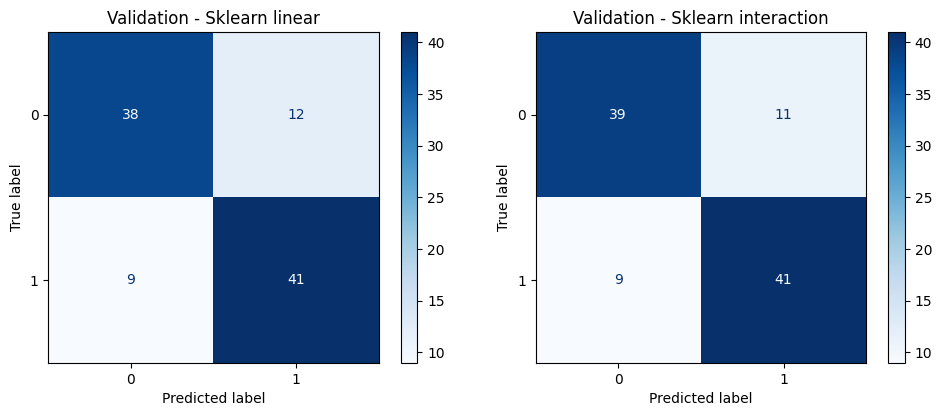

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Modelli scelti per il confronto
linear_model = models_dict[("Sklearn", "linear")]
interaction_model = models_dict[("Sklearn", "interaction")]

# Dati trasformati
Xval_linear = apply_basis_transformation(X_val_scaled, "linear")
Xval_interaction = apply_basis_transformation(X_val_scaled, "interaction")

# Predizioni
yval_pred_linear = linear_model.predict(Xval_linear)
yval_pred_interaction = interaction_model.predict(Xval_interaction)

# Plot affiancato
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    yval_pred_linear,
    cmap="Blues",
    values_format="d",
    ax=axes[0]
)
axes[0].set_title("Validation - Sklearn linear")

ConfusionMatrixDisplay.from_predictions(
    y_val,
    yval_pred_interaction,
    cmap="Blues",
    values_format="d",
    ax=axes[1]
)
axes[1].set_title("Validation - Sklearn interaction")

plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Modello finale
final_model = models_dict[("Sklearn", "interaction")]

# Test trasformato
Xtest_interaction = apply_basis_transformation(X_test_scaled, "interaction")

# Predizioni
ytest_pred_interaction = final_model.predict(Xtest_interaction)

# Metriche
test_metrics = pd.DataFrame([{
    "Model": "Sklearn",
    "Basis": "interaction",
    "Test Accuracy": accuracy_score(y_test, ytest_pred_interaction),
    "Test Precision": precision_score(y_test, ytest_pred_interaction),
    "Test Recall": recall_score(y_test, ytest_pred_interaction),
    "Test F1": f1_score(y_test, ytest_pred_interaction)
}])

test_metrics.round(3)

,Model,Basis,Test Accuracy,Test Precision,Test Recall,Test F1
0,Sklearn,interaction,0.73,0.756,0.68,0.716


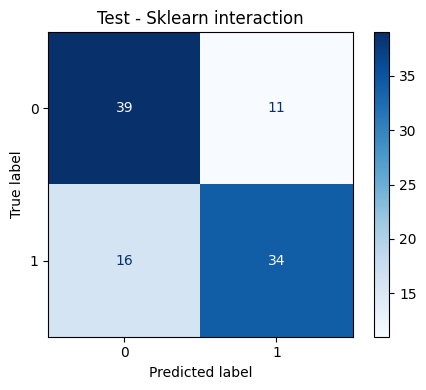

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    ytest_pred_interaction,
    cmap="Blues",
    values_format="d",
    ax=ax
)
ax.set_title("Test - Sklearn interaction")

plt.tight_layout()
plt.show()

### Osservazione finale sul test set

Il modello con interaction mostrava un leggero miglioramento sul validation set, ma questo non viene confermato sul test set.

In particolare, si osserva un aumento degli errori sulla classe positiva (false negative).

Questo evidenzia un aspetto importante:

- miglioramenti piccoli sul validation set possono non essere robusti;
- il test set serve proprio a verificare la reale capacità di generalizzazione.

Per questo motivo, nella pratica, è importante non basarsi su differenze marginali e considerare anche la semplicità del modello.

Cosa fare?

- accettiamo il modello
- ripetere tutto con nuovo split oppure utilizzare cross-validation

# Continuiamo con la Regressione

### Richiamo: analisi delle relazioni per la regressione dagli scatter plots

Dall’analisi dei grafici feature–target emergono alcuni pattern utili:

- **Distance** e **Obstacles**  
  La qualità del segnale decresce all’aumentare di queste variabili, in modo non lineare.  
  → possibili trasformazioni: \( 1/x \), \( log(x) \)

- **Temperature**  
  Andamento a campana: valori intermedi → qualità più alta.  
  → possibile termine quadratico: \( x^2 \)

- **Humidity**  
  Comportamento simile alla temperatura, ma meno marcato.  
  → possibile effetto non lineare, da valutare

---

### Osservazione

A differenza della classificazione, qui possiamo osservare direttamente la relazione tra feature e target.

Per questo motivo, utilizzeremo **trasformazioni mirate**, guidate dai grafici,
invece di trasformazioni generiche applicate a tutte le feature.

In [16]:
# definizione modello lineare. Lo stesso visto anche in Excercise -> 1. Linear_regression_solution

import numpy as np

def predict(X, weights):
    """
    Calcola le previsioni usando il modello lineare y = X*w.
    
    Parametri:
    X -- matrice di input di shape (m, n+1) con una colonna di 1 aggiunta per il termine di bias
    weights -- vettore dei pesi di shape (n+1, 1)
    
    Restituisce:
    predictions -- vettore delle previsioni di shape (m, 1)
    """
    return np.dot(X, weights)

def compute_cost(X, y, weights):
    """
    Calcola la funzione di costo MSE (Mean Squared Error) per la regressione lineare.
    
    Parametri:
    X -- matrice di input di shape (m, n+1) con una colonna di 1 aggiunta per il termine di bias
    y -- vettore target di shape (m, 1)
    weights -- vettore dei pesi di shape (n+1, 1)
    
    Restituisce:
    cost -- valore dello scarto quadratico medio
    """
    m = X.shape[0]  # numero di esempi
    
    # Calcola le previsioni
    predictions = predict(X, weights)
    
    # Calcola la differenza quadratica
    diff = predictions - y
    squared_diff = np.square(diff)
    
    # Calcola la media degli errori quadratici
    cost = (1/(2*m)) * np.sum(squared_diff)
    
    return cost

def compute_gradient(X, y, weights):
    """
    Calcola il gradiente della funzione di costo rispetto ai pesi.
    
    Parametri:
    X -- matrice di input di shape (m, n+1) con una colonna di 1 aggiunta per il termine di bias
    y -- vettore target di shape (m, 1)
    weights -- vettore dei pesi di shape (n+1, 1)
    
    Restituisce:
    gradient -- vettore del gradiente di shape (n+1, 1)
    """
    m = X.shape[0]  # numero di esempi
    
    # Calcola le previsioni
    predictions = predict(X, weights)
    
    # Calcola le differenze tra previsioni e valori reali
    diff = predictions - y
    
    # Calcola il gradiente
    gradient = (1/m) * np.dot(X.T, diff)
    
    return gradient

def gradient_descent(X, y, weights, learning_rate, num_iterations, print_every=100):
    """
    Esegue l'algoritmo di discesa del gradiente per trovare i pesi ottimali.
    
    Parametri:
    X -- matrice di input di shape (m, n)
    y -- vettore target di shape (m, 1)
    weights -- vettore iniziale dei pesi di shape (n+1, 1)
    learning_rate -- parametro di apprendimento
    num_iterations -- numero di iterazioni
    print_every -- frequenza di stampa dei costi durante l'addestramento
    
    Restituisce:
    weights -- vettore dei pesi ottimizzati
    costs -- lista dei costi per ogni iterazione di stampa
    """
    # Aggiungi colonna di 1 per il termine di bias
    m = X.shape[0]
    X_with_bias = np.c_[np.ones((m, 1)), X]
    
    costs = []
    
    for i in range(num_iterations):
        # Calcola il gradiente
        gradient = compute_gradient(X_with_bias, y, weights)
        
        # Aggiorna i pesi
        weights = weights - learning_rate * gradient
        
        # Calcola e salva il costo ogni print_every iterazioni
        if i % print_every == 0:
            cost = compute_cost(X_with_bias, y, weights)
            costs.append(cost)
            print(f"Iterazione {i}, Errore: {cost}")
            print(f"Iterazione {i}, Pesi: [{', '.join([f'{w[0]:.6f}' for w in weights])}]")

    return weights, costs

# Esempio di utilizzo
def run_linear_regression(X, y, learning_rate=0.01, num_iterations=1000):
    """
    Esegue la regressione lineare su X e y.
    
    Parametri:
    X -- matrice di input di shape (m, n)
    y -- vettore target di shape (m, 1)
    learning_rate -- parametro di apprendimento
    num_iterations -- numero di iterazioni
    
    Restituisce:
    weights -- vettore dei pesi ottimizzati
    costs -- lista dei costi
    """
    # Inizializza i pesi a zero
    n = X.shape[1]  # numero di feature
    weights = np.zeros((n + 1, 1))  # +1 per il termine di bias
    
    # Esegui la discesa del gradiente
    final_weights, costs = gradient_descent(X, y, weights, learning_rate, num_iterations)
    print("\n Errore Finale")
    print(f"Errore: {costs[-1]}")
    print("\nPesi finali:")
    print(f"w_0 (intercetta): {final_weights[0][0]}")
    for i in range(1, len(final_weights)):
        print(f"w_{i}: {final_weights[i][0]}")
    
    return final_weights, costs

### Ordine delle trasformazioni

Nella sezione di classificazione abbiamo applicato le trasformazioni dopo la normalizzazione delle feature.

Questo approccio è accettabile nella classificazione, dove l'obiettivo è rendere più flessibile lo spazio delle feature per separare le classi.

Nella regressione, invece, le trasformazioni sono guidate dall'analisi dei grafici tra feature e target.

Per questo motivo, è importante applicare le trasformazioni sui dati originali, in modo che riflettano correttamente i pattern osservati.

La normalizzazione viene quindi applicata successivamente, per rendere le feature comparabili e migliorare la stabilità del modello.

In [17]:
# Dopo lo split, X_train, X_val e X_test sono array numpy.
# Ricostruiamo i DataFrame assegnando i nomi delle colonne nell'ordine corretto,
# così possiamo selezionare e trasformare le feature per nome.

feature_names = ["distance", "obstacles", "temperature", "humidity"]

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_val_df = pd.DataFrame(X_val, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

## Dalla regressione lineare alle trasformazioni delle feature

Se usiamo direttamente le feature originali, il modello può rappresentare solo relazioni lineari rispetto a ciascuna variabile.

Per modellare relazioni più complesse, dobbiamo costruire nuove feature trasformate. 

In questo modo il modello resta lineare nei pesi, ma può descrivere andamenti non lineari rispetto alle variabili originali.

In [18]:
# Funzioni di trasformazione delle feature

def add_quadratic_feature(x):
    return np.square(x)

def add_log_feature(x):
    return np.log(x + 1)

def add_inverse_feature(x):
    return 1 / (x + 1)

In [19]:
def build_features(df,
                   use_log_distance=False,
                   use_inv_obstacles=False,
                   use_temp_sq=False,
                   use_hum_sq=False):
    """
    Costruisce un nuovo insieme di feature a partire dai dati originali.

    Parametri:
    - df: DataFrame con le feature originali
    - use_log_distance: aggiunge log(distance + 1)
    - use_inv_obstacles: aggiunge 1 / (obstacles + 1)
    - use_temp_sq: aggiunge temperature^2
    - use_hum_sq: aggiunge humidity^2

    Restituisce:
    - X_new: DataFrame con feature originali + trasformazioni selezionate
    """
    
    # Creiamo un nuovo DataFrame vuoto con lo stesso indice
    X_new = pd.DataFrame(index=df.index)

    # Manteniamo sempre le feature originali
    X_new["distance"] = df["distance"]
    X_new["obstacles"] = df["obstacles"]
    X_new["temperature"] = df["temperature"]
    X_new["humidity"] = df["humidity"]

    # Aggiungiamo le trasformazioni solo se richieste

    # Trasformazione logaritmica per la distanza
    if use_log_distance:
        X_new["log_distance"] = np.log(df["distance"] + 1)

    # Trasformazione inversa per il numero di ostacoli
    if use_inv_obstacles:
        X_new["inv_obstacles"] = 1 / (df["obstacles"] + 1)

    # Termine quadratico per la temperatura
    if use_temp_sq:
        X_new["temperature_sq"] = df["temperature"] ** 2

    # Termine quadratico per l'umidità
    if use_hum_sq:
        X_new["humidity_sq"] = df["humidity"] ** 2

    return X_new

In [20]:
# Definiamo diverse configurazioni di feature.
# Ogni configurazione attiva alcune trasformazioni e ne disattiva altre,
# così possiamo valutarne l'impatto sul modello di regressione.

configs = [
    ("baseline", {}),  # solo feature originali
    
    ("log_distance", {
        "use_log_distance": True
    }),  # aggiunge log(distance)
    
    ("inv_obstacles", {
        "use_inv_obstacles": True
    }),  # aggiunge 1/(obstacles + 1)
    
    ("temperature_sq", {
        "use_temp_sq": True
    }),  # aggiunge temperature^2
    
    ("humidity_sq", {
        "use_hum_sq": True
    }),  # aggiunge humidity^2
    
    ("all_transforms", {
        "use_log_distance": True,
        "use_inv_obstacles": True,
        "use_temp_sq": True,
        "use_hum_sq": True
    })  # usa tutte le trasformazioni insieme
]

### Confronto tra diverse trasformazioni

Valutiamo l'impatto delle trasformazioni sulle prestazioni del modello.

Partiamo da un modello lineare base e introduciamo progressivamente nuove feature,
per capire quali contribuiscono realmente a migliorare la qualità della previsione.

Useremo:
- RMSE per misurare l'errore
- R² per valutare la qualità del fit

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(Xtr, ytr, Xval, yval):
    
    # Creiamo un modello di regressione lineare
    model = LinearRegression()
    
    # Addestriamo il modello sui dati di training
    model.fit(Xtr, ytr)

    # Predizioni su training e validation
    ytr_pred = model.predict(Xtr)
    yval_pred = model.predict(Xval)

    # Calcolo delle metriche:
    # RMSE -> errore medio (più basso è meglio)
    # R² -> qualità del fit (più alto è meglio)
    return {
        "Train RMSE": np.sqrt(mean_squared_error(ytr, ytr_pred)),
        "Val RMSE": np.sqrt(mean_squared_error(yval, yval_pred)),
        "Train R2": r2_score(ytr, ytr_pred),
        "Val R2": r2_score(yval, yval_pred),
    }

In [22]:
results = []

# Iteriamo su tutte le configurazioni definite
for name, params in configs:
    
    # 1. Costruiamo le feature trasformate sui dati originali
    Xtr = build_features(X_train_df, **params)
    Xval = build_features(X_val_df, **params)

    # 2. Normalizziamo dopo il feature engineering
    # Fit solo sul training set, poi trasformazione di training e validation
    scaler = StandardScaler()
    Xtr_scaled = scaler.fit_transform(Xtr)
    Xval_scaled = scaler.transform(Xval)

    # 3. Addestriamo e valutiamo il modello
    metrics = evaluate_model(Xtr_scaled, y_train, Xval_scaled, y_val)

    # 4. Salviamo i risultati per costruire la tabella finale
    results.append({
        "Model": name,
        **metrics
    })

In [23]:
results_df = pd.DataFrame(results)

# Ordiniamo i modelli per RMSE sul validation set
results_df = results_df.sort_values(by="Val RMSE").reset_index(drop=True)

results_df.round(3)

,Model,Train RMSE,Val RMSE,Train R2,Val R2
0,log_distance,0.395,0.396,0.376,0.371
1,humidity_sq,0.405,0.397,0.344,0.369
2,baseline,0.405,0.397,0.344,0.369
3,inv_obstacles,0.405,0.398,0.344,0.365
4,temperature_sq,0.403,0.400,0.350,0.361
5,all_transforms,0.392,0.400,0.384,0.360


### Analisi dei risultati

Le trasformazioni introdotte portano solo miglioramenti molto limitati rispetto al modello lineare di base.

In particolare:

- **log_distance** è la trasformazione che ottiene le prestazioni migliori sul validation set;
- **humidity_sq** produce risultati quasi identici al baseline;
- le altre trasformazioni non migliorano in modo significativo il modello;
- l'uso di **tutte le trasformazioni insieme** migliora leggermente il training set, ma non il validation set.

Questo suggerisce che, nel problema considerato, le relazioni non lineari osservate nei grafici esistono, ma non sono abbastanza forti da produrre un vantaggio netto nelle prestazioni del modello.

---

### Conclusione

Anche se le trasformazioni rendono il modello più espressivo, in questo caso il beneficio è molto contenuto.

Questo è un risultato importante:  
**non sempre aumentare la complessità del modello porta a un miglioramento reale**.

Per questo motivo, prima di scegliere il modello finale, può essere utile esplorare un ultimo aspetto:
la presenza di possibili **interazioni tra feature**.

In [24]:
def build_features_extra(df,
                         use_distance_obstacles=False,
                         use_temp_humidity=False):
    """
    Costruisce un nuovo insieme di feature per testare trasformazioni aggiuntive.

    Parametri:
    - df: DataFrame con le feature originali
    - use_distance_obstacles: aggiunge distance * obstacles
    - use_temp_humidity: aggiunge temperature * humidity

    Restituisce:
    - X_new: DataFrame con feature originali + nuove trasformazioni selezionate
    """

    X_new = pd.DataFrame(index=df.index)

    # Manteniamo sempre le feature originali
    X_new["distance"] = df["distance"]
    X_new["obstacles"] = df["obstacles"]
    X_new["temperature"] = df["temperature"]
    X_new["humidity"] = df["humidity"]

    # Nuove trasformazioni candidate
    if use_distance_obstacles:
        X_new["distance_obstacles"] = df["distance"] * df["obstacles"]

    if use_temp_humidity:
        X_new["temp_humidity"] = df["temperature"] * df["humidity"]

    return X_new

In [25]:
# Definiamo alcune nuove configurazioni per testare interazioni mirate tra feature.

extra_configs = [
    ("distance_obstacles", {
        "use_distance_obstacles": True
    }),
    
    ("temp_humidity", {
        "use_temp_humidity": True
    }),
    
    ("both_interactions", {
        "use_distance_obstacles": True,
        "use_temp_humidity": True
    })
]

In [26]:
extra_results = []

# Iteriamo sulle nuove configurazioni ma riutilizziamo la funzione evaluate model
for name, params in extra_configs:
    
    # Costruiamo le nuove feature sui dati originali
    Xtr = build_features_extra(X_train_df, **params)
    Xval = build_features_extra(X_val_df, **params)

    # Normalizziamo dopo il feature engineering
    scaler = StandardScaler()
    Xtr_scaled = scaler.fit_transform(Xtr)
    Xval_scaled = scaler.transform(Xval)

    # Addestriamo e valutiamo il modello
    metrics = evaluate_model(Xtr_scaled, y_train, Xval_scaled, y_val)

    # Salviamo i risultati
    extra_results.append({
        "Model": name,
        **metrics
    })

In [27]:
extra_results_df = pd.DataFrame(extra_results)
extra_results_df = extra_results_df.sort_values(by="Val RMSE").reset_index(drop=True)

extra_results_df.round(3)

,Model,Train RMSE,Val RMSE,Train R2,Val R2
0,distance_obstacles,0.405,0.397,0.344,0.369
1,both_interactions,0.405,0.399,0.345,0.363
2,temp_humidity,0.405,0.399,0.345,0.362


### Scelta del modello finale

Dai risultati ottenuti sul validation set, il modello migliore è quello che utilizza
la trasformazione logaritmica della distanza.

Le altre trasformazioni e le interazioni tra feature non portano miglioramenti
significativi, e in alcuni casi peggiorano le prestazioni.

Per questo motivo, scegliamo un modello semplice:
- feature originali
- trasformazione log(distance)

---

### Considerazioni finali

Questo risultato evidenzia un aspetto importante:

- non tutte le trasformazioni migliorano il modello;
- aumentare la complessità non garantisce prestazioni migliori;
- è fondamentale validare ogni scelta tramite dati.

In questo caso, il modello lineare di base era già una buona approssimazione,
e le trasformazioni introducono solo miglioramenti marginali.

In [28]:
# Costruiamo le feature del modello finale:
# utilizziamo le feature originali + log(distance)

Xtr = build_features(X_train_df, use_log_distance=True)
Xval = build_features(X_val_df, use_log_distance=True)
Xtest = build_features(X_test_df, use_log_distance=True)

# Applichiamo la normalizzazione:
# fit solo sul training set, poi trasformiamo validation e test
scaler = StandardScaler()

Xtr_scaled = scaler.fit_transform(Xtr)
Xval_scaled = scaler.transform(Xval)
Xtest_scaled = scaler.transform(Xtest)

# Creiamo e addestriamo il modello di regressione lineare
model = LinearRegression()
model.fit(Xtr_scaled, y_train)

# Effettuiamo le predizioni sul test set
y_test_pred = model.predict(Xtest_scaled)

# Calcoliamo le metriche sul test set
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

# Stampiamo i risultati finali
print(f"Test RMSE: {rmse_test:.3f}")
print(f"Test R2: {r2_test:.3f}")

Test RMSE: 0.420
Test R2: 0.294


In [29]:
# Confronto validation vs test per verificare la generalizzazione

y_val_pred = model.predict(Xval_scaled)

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val = r2_score(y_val, y_val_pred)

print(f"Validation RMSE: {rmse_val:.3f}")
print(f"Validation R2: {r2_val:.3f}")

Validation RMSE: 0.396
Validation R2: 0.371


### Valutazione finale sul test set

Il modello selezionato mostra un peggioramento sul test rispetto al validation, indicando una capacità di generalizzazione limitata.

### Conclusione

- i miglioramenti su validation non si trasferiscono al test;
- aumentare la complessità non ha portato benefici reali;
- il limite principale è nelle feature disponibili, non nel modello.

### Altre trasformazioni (opzionale)

In alcuni casi è possibile utilizzare trasformazioni generiche
(quadratiche, esponenziali, trigonometriche).

Questo approccio è più flessibile ma meno interpretabile, e va utilizzato quando non si hanno indicazioni chiare dai dati.

In [30]:
# Trasformazioni generiche delle feature
# Da usare come base per sperimentare nuove rappresentazioni

def generic_basis_transform(X, basis_type="quadratic"):
    """
    Applica trasformazioni generiche alle feature.

    Parametri:
    - X: array numpy (n_samples, n_features)
    - basis_type: tipo di trasformazione
    
    Restituisce:
    - X_transformed: array trasformato
    """

    if basis_type == "quadratic":
        # Aggiunge i termini quadratici
        X_quad = X ** 2
        return np.hstack([X, X_quad])

    elif basis_type == "exponential":
        # Aggiunge exp(-x)
        X_exp = np.exp(-X)
        return np.hstack([X, X_exp])

    elif basis_type == "trigonometric":
        # Aggiunge sin(x) e cos(x)
        X_sin = np.sin(X)
        X_cos = np.cos(X)
        return np.hstack([X, X_sin, X_cos])

    else:
        # Nessuna trasformazione
        return X

In [31]:
def add_interaction_features(X):
    """
    Aggiunge termini di interazione tra tutte le coppie di feature.

    Parametri:
    - X: array numpy di shape (n_samples, n_features)

    Restituisce:
    - X_transformed: array con feature originali + interazioni
    """
    
    n_features = X.shape[1]
    interaction_terms = []

    # Per ogni coppia di feature diverse, calcoliamo il prodotto x_i * x_j
    for i in range(n_features):
        for j in range(i + 1, n_features):
            interaction = (X[:, i] * X[:, j]).reshape(-1, 1)
            interaction_terms.append(interaction)

    # Se esistono interazioni, le aggiungiamo alle feature originali
    if interaction_terms:
        X_interactions = np.hstack(interaction_terms)
        X_transformed = np.hstack([X, X_interactions])
    else:
        X_transformed = X

    return X_transformed